# Prédiction de la note moyenne de films 

Projet de fouilles de données  

Objectif : prédire la variable **`vote_average`** (note moyenne d'un film) avant la sortie du film

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.prepare_data import load_data, prepare_base_dataframe
from src.encoding import encode_all
from src.modeling import (baseline_metrics_from_y, train_linear_regression, train_random_forest, evaluate)
from src.visualization import (plot_model_comparison, plot_predictions, plot_error_distribution, plot_accuracy_comparison)

## Analyse exploratoire des données (EDA)

In [2]:
df = load_data("data/tmdb_movies_data.csv")
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [4]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [5]:
# valeurs manquantes
manquante_ratio = df.isna().mean().sort_values(ascending=False) * 100
manquante_ratio

homepage                72.979937
tagline                 25.989324
keywords                13.740107
production_companies     9.479109
cast                     0.699429
director                 0.404933
genres                   0.211669
imdb_id                  0.092030
overview                 0.036812
revenue                  0.000000
budget                   0.000000
popularity               0.000000
id                       0.000000
runtime                  0.000000
original_title           0.000000
release_date             0.000000
vote_count               0.000000
vote_average             0.000000
release_year             0.000000
budget_adj               0.000000
revenue_adj              0.000000
dtype: float64

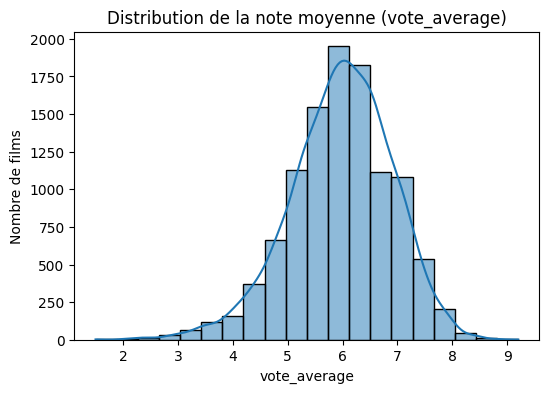

In [6]:
plt.figure(figsize=(6, 4))
sns.histplot(df["vote_average"], bins=20, kde=True)
plt.title("Distribution de la note moyenne (vote_average)")
plt.xlabel("vote_average")
plt.ylabel("Nombre de films")
plt.show()

In [7]:
all_genres = []
for g in df["genres"].dropna():
    all_genres.extend([p.strip() for p in g.split("|") if p.strip()])
genre_counts = {}
for genre in all_genres:
    if genre in genre_counts:
        genre_counts[genre] += 1
    else:
        genre_counts[genre] = 1

# top 10
top_10 = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:10]
top_10


[('Drama', 4761),
 ('Comedy', 3793),
 ('Thriller', 2908),
 ('Action', 2385),
 ('Romance', 1712),
 ('Horror', 1637),
 ('Adventure', 1471),
 ('Crime', 1355),
 ('Family', 1231),
 ('Science Fiction', 1230)]

- Certaines colonnes texte (`genres`, `cast`, `keywords`...) contiennent beaucoup de valeurs manquantes
  ou des valeurs très variées
- La distribution de `vote_average` est relativement concentrée autour de 6.
- Les genres sont nombreux mais quelques genres dominent.  

## Préparation de la base de données

In [8]:
df = load_data("data/tmdb_movies_data.csv")
df_base = prepare_base_dataframe(df)
df_base.head()

,runtime,genres,cast,director,production_companies,release_year,keywords,vote_average
0,124,Action|Adventure|Science Fiction|Thriller,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,Universal Studios|Amblin Entertainment|Legenda...,2015,monster|dna|tyrannosaurus rex|velociraptor|island,6.5
1,120,Action|Adventure|Science Fiction|Thriller,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,Village Roadshow Pictures|Kennedy Miller Produ...,2015,future|chase|post-apocalyptic|dystopia|australia,7.1
2,119,Adventure|Science Fiction|Thriller,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,Summit Entertainment|Mandeville Films|Red Wago...,2015,based on novel|revolution|dystopia|sequel|dyst...,6.3
3,136,Action|Adventure|Science Fiction|Fantasy,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,Lucasfilm|Truenorth Productions|Bad Robot,2015,android|spaceship|jedi|space opera|3d,7.5
4,137,Action|Crime|Thriller,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,Universal Pictures|Original Film|Media Rights ...,2015,car race|speed|revenge|suspense|car,7.3


In [9]:
df_base.describe()

,runtime,release_year,vote_average
count,10866.000000,10866.000000,10866.000000
mean,102.070863,2001.322658,5.974922
std,31.381405,12.812941,0.935142
min,0.000000,1960.000000,1.500000
25%,90.000000,1995.000000,5.400000
50%,99.000000,2006.000000,6.000000
75%,111.000000,2011.000000,6.600000
max,900.000000,2015.000000,9.200000


In [10]:
manquante_ratio = df_base.isna().mean().sort_values(ascending=False) * 100
manquante_ratio

runtime                 0.0
genres                  0.0
cast                    0.0
director                0.0
production_companies    0.0
release_year            0.0
keywords                0.0
vote_average            0.0
dtype: float64

In [11]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   runtime               10866 non-null  int64  
 1   genres                10866 non-null  object 
 2   cast                  10866 non-null  object 
 3   director              10866 non-null  object 
 4   production_companies  10866 non-null  object 
 5   release_year          10866 non-null  int64  
 6   keywords              10866 non-null  object 
 7   vote_average          10866 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 679.2+ KB


## Séparations

In [12]:
# séparation features/target
X = df_base.drop(columns=["vote_average"])
y = df_base["vote_average"]

In [13]:
# séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train.shape, X_test.shape

((8692, 7), (2174, 7))

## Encodage des variables catégorielles et textuelles

- Top 5 genres → variables binaires `genre_*`
- Top 10 acteurs principaux, réalisateurs, compagnies → colonnes `actor_*`, `director_*`, `company_*`
- TF-IDF sur `keywords` (max_features = 1000, min_df = 10)
- Suppression des colonnes texte brutes


In [15]:
X_train_enc, X_test_enc = encode_all(X_train, X_test)
X_train_enc.shape, X_test_enc.shape

((8692, 965), (2174, 965))

In [16]:
# apercu des colonnes encodés
X_train_enc.iloc[:5, :15]

,runtime,release_year,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Horror,genre_Adventure,genre_Crime,genre_Science_Fiction,genre_Family,actor_Unknown,actor_Nicolas_Cage,actor_Clint_Eastwood
5684,91,2013,0,1,0,0,1,0,0,0,0,0,0,0,0
2457,127,1999,1,0,0,0,0,0,0,0,0,0,0,0,0
393,85,2015,0,1,0,0,0,1,0,0,0,0,0,0,0
9950,181,1971,1,0,0,0,1,0,0,0,0,0,0,0,0
3037,96,2008,1,0,0,0,0,0,0,0,0,0,0,0,0


## Modélisation : baseline et modèles de régression

In [17]:
baseline = baseline_metrics_from_y(y_train, y_test)
baseline

{'value': np.float64(5.976449608835711),
 'mse': 0.8695824806103398,
 'r2': -6.706428314062762e-05,
 'r2_percent': -0.006706428314062762,
 'acc_0.5': np.float64(42.870285188592455),
 'acc_1': np.float64(73.09107635694572),
 'acc_2': np.float64(96.55013799448022),
 'pred': array([5.97644961, 5.97644961, 5.97644961, ..., 5.97644961, 5.97644961,
        5.97644961])}

In [18]:
lineaire_model = train_linear_regression(X_train_enc, y_train)
lineaire = evaluate(lineaire_model, X_test_enc, y_test)
lineaire

{'mse': 0.733252177792469,
 'r2': 0.1567201856350111,
 'r2_percent': 15.672018563501112,
 'acc_0.5': np.float64(45.400183992640294),
 'acc_1': np.float64(77.36890524379025),
 'acc_2': np.float64(97.33210671573137),
 'pred': array([5.93427962, 5.8687832 , 7.84139698, ..., 6.72465873, 6.01387247,
        5.71116342])}

In [19]:
rf_model = train_random_forest(X_train_enc, y_train)
rf = evaluate(rf_model, X_test_enc, y_test)
rf

{'mse': 0.6163292497286159,
 'r2': 0.2911879009161831,
 'r2_percent': 29.11879009161831,
 'acc_0.5': np.float64(50.78196872125115),
 'acc_1': np.float64(82.10671573137076),
 'acc_2': np.float64(98.4360625574977),
 'pred': array([5.871, 5.755, 7.044, ..., 6.215, 5.299, 5.134])}

In [20]:
results = pd.DataFrame({
    "Baseline": baseline,
    "Régression linéaire": lineaire,
    "Random Forest": rf,
}).T[["mse", "r2", "acc_0.5", "acc_1", "acc_2"]]

results


,mse,r2,acc_0.5,acc_1,acc_2
Baseline,0.869582,-0.000067,42.870285,73.091076,96.550138
Régression linéaire,0.733252,0.15672,45.400184,77.368905,97.332107
Random Forest,0.616329,0.291188,50.781969,82.106716,98.436063


## Validation croisée sur Random Forest

In [21]:
rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
  )

cv_scores = cross_val_score(
    rf_cv,
    X_train_enc,
    y_train,
    cv=5, # 5 entrainements
    scoring="neg_mean_squared_error",
    n_jobs=-1,
  )

In [22]:
rmse_scores = np.sqrt(-cv_scores)
rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

print(f"RMSE moyen (CV 5-fold) : {rmse_mean:.4f}")
print(f"RMSE écart-type        : {rmse_std:.4f}")

RMSE moyen (CV 5-fold) : 0.8001
RMSE écart-type        : 0.0126


## Visualisation des performances des modèles

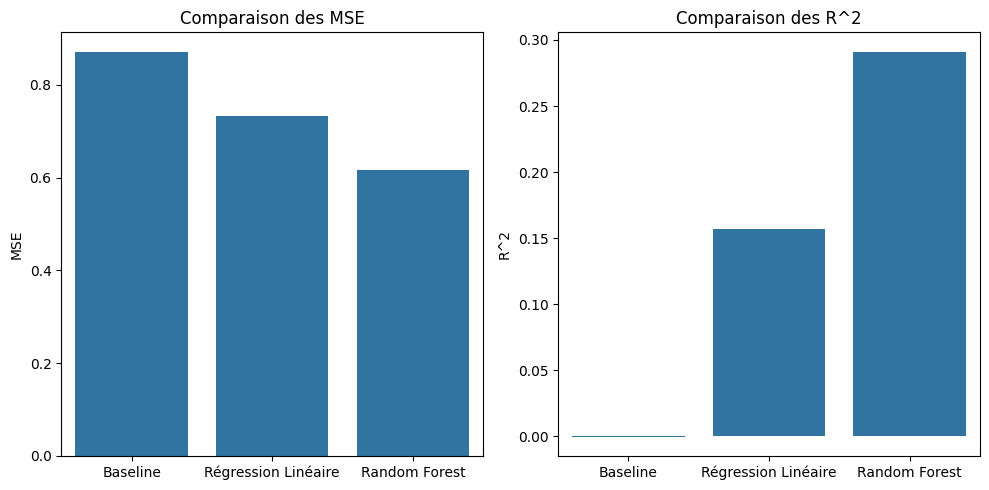

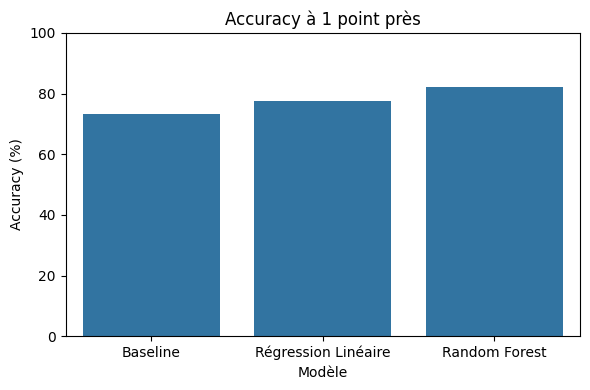

In [23]:
results = {
    "baseline": baseline,
    "linear_regression": lineaire,
    "random_forest": rf,
    "y_test": y_test,
    "y_pred_linear": lineaire["pred"],
    "y_pred_rf": rf["pred"],
}

plot_model_comparison(results)
plot_accuracy_comparison(results)


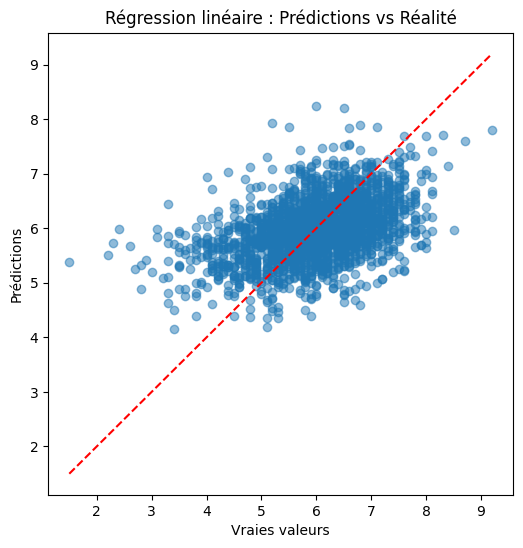

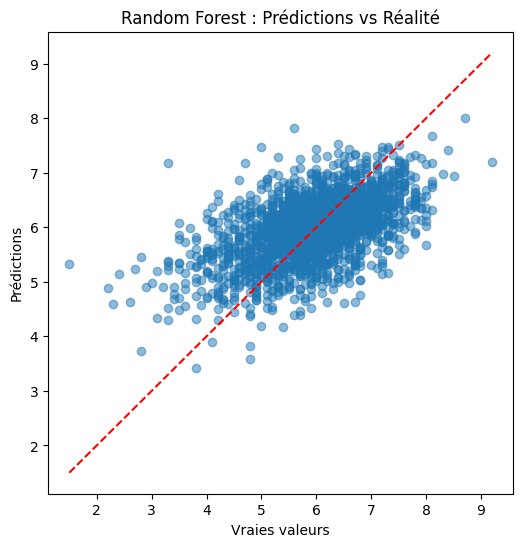

In [24]:
plot_predictions(y_test, results["y_pred_linear"], "Régression linéaire : Prédictions vs Réalité")
plot_predictions(y_test, results["y_pred_rf"], "Random Forest : Prédictions vs Réalité")

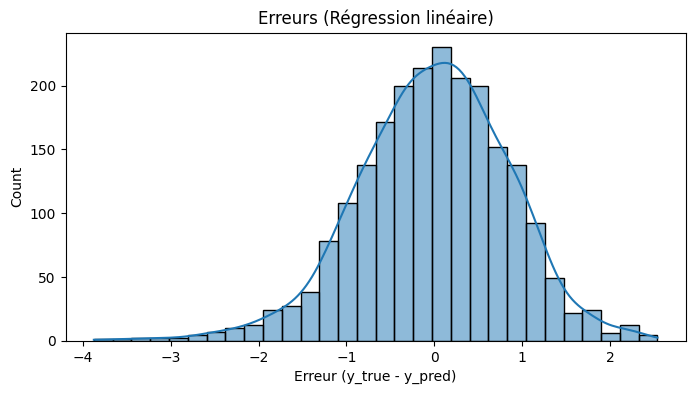

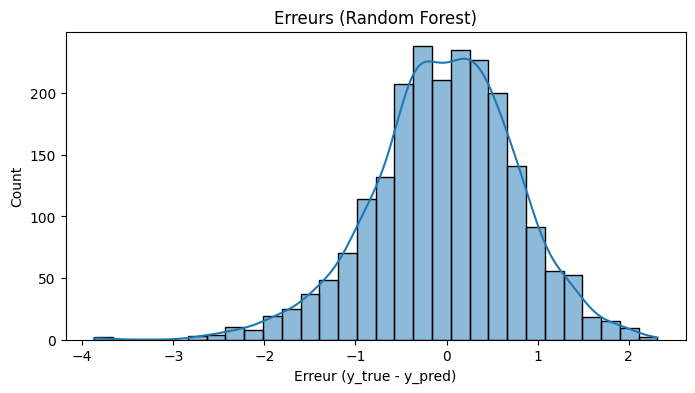

In [25]:
plot_error_distribution(y_test, results["y_pred_linear"], "Erreurs (Régression linéaire)")
plot_error_distribution(y_test, results["y_pred_rf"], "Erreurs (Random Forest)")